## Bank Transaction Category Prediction Project

##### This challenge aims to develop a robust LightGBM model to predict the categories of bank transactions.

## Importing libraries and packages

In [ ]:
# Data Manipulation & Analysis
import pandas as pd
import numpy as np

# Data Preprocessing & Feature Engineering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# Text Processing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
import string

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation

# Model Evaluation & Metrics
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, roc_curve, auc

# Imbalanced Data Handling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Utilies
import warnings
import gdown

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

/usr/local/lib/python3.11/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [ ]:
!pip install gdown

In [ ]:
shared_url_1 = 'https://drive.google.com/file/d/1aBsNsj1IuGMpaOeWi2rt29k_d3FZwZdT/view?usp=drive_link'
file_id_1 = '1aBsNsj1IuGMpaOeWi2rt29k_d3FZwZdT'
download_url_1 = f'https://drive.google.com/uc?id={file_id_1}'
gdown.download(download_url_1, 'bank_transaction.csv', quiet=False)

shared_url_2 = 'https://drive.google.com/file/d/14ZSqf0Ti_A2Rngz8bs5GTgiFGTRGg4cx/view?usp=drive_link'
file_id_2 = '14ZSqf0Ti_A2Rngz8bs5GTgiFGTRGg4cx'
download_url_2 = f'https://drive.google.com/uc?id={file_id_2}'
gdown.download(download_url_2, 'user_profile.csv', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1aBsNsj1IuGMpaOeWi2rt29k_d3FZwZdT
To: /content/bank_transaction.csv
100%|██████████| 26.2M/26.2M [00:00<00:00, 132MB/s]
Downloading...
From: https://drive.google.com/uc?id=14ZSqf0Ti_A2Rngz8bs5GTgiFGTRGg4cx
To: /content/user_profile.csv
100%|██████████| 39.8k/39.8k [00:00<00:00, 72.3MB/s]


'user_profile.csv'

In [ ]:
transactions = pd.read_csv('bank_transaction.csv')
profiles = pd.read_csv('user_profile.csv')

## Data understanding

In [ ]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258779 entries, 0 to 258778
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   client_id    258779 non-null  int64  
 1   bank_id      258779 non-null  int64  
 2   account_id   258779 non-null  int64  
 3   txn_id       258779 non-null  int64  
 4   txn_date     258779 non-null  object 
 5   description  258779 non-null  object 
 6   amount       258779 non-null  float64
 7   category     258522 non-null  object 
dtypes: float64(1), int64(4), object(3)
memory usage: 15.8+ MB


In [ ]:
transactions.shape

(258779, 8)

In [ ]:
transactions.head(10)

,client_id,bank_id,account_id,txn_id,txn_date,description,amount,category
0,1,1,1,4,2023-09-29 00:00:00,Earnin PAYMENT Donat...,20.000,Loans
1,1,1,1,3,2023-08-14 00:00:00,ONLINE TRANSFER FROM NDonatas DanyalDA O CARSO...,25.000,Transfer Credit
2,1,1,1,5,2023-09-25 00:00:00,MONEY TRANSFER AUTHOR...,20.000,Loans
3,1,1,2,1,2023-06-02 00:00:00,ONLINE TRANSFER FROM CARSON N EVERYDAY CHECKIN...,16.000,Transfer Credit
4,1,1,2,2,2023-06-01 00:00:00,ONLINE TRANSFER FROM CARSON N EVERYDAY CHECKIN...,4.000,Transfer Credit
5,2,1,2,77,2023-07-10 00:00:00,Deposit from 360 Checking 924,1000.000,Transfer Deposit
6,2,1,2,55,2023-07-26 00:00:00,ISD #11,184.330,Payroll
7,2,1,2,52,2023-06-26 00:00:00,Deposit from 360 Checking 924,10.000,Transfer Deposit
8,2,1,2,51,2023-09-09 00:00:00,360 Checking Card Adjustment Signature (Credit...,2.628,Uncategorized
9,2,1,2,49,2023-06-28 00:00:00,ISD #11,171.356,Payroll


In [ ]:
transactions.isnull().sum()

,0
client_id,0
bank_id,0
account_id,0
txn_id,0
txn_date,0
description,0
amount,0
category,257


In [ ]:
transactions.duplicated().sum()

0

There are 257 null values in the 'category' column of the bank _transaction.csv.There are no duplicate values.

In [ ]:
transactions.nunique()

,0
client_id,880
bank_id,990
account_id,1131
txn_id,190505
txn_date,7183
description,102108
amount,29120
category,33


In [ ]:
transactions["category"].value_counts()

,count
category,
Uncategorized,29392
Third Party,28714
Restaurants,26367
Transfer Credit,21561
Loans,19605
Convenience Stores,18630
Supermarkets and Groceries,16750
Transfer Debit,15114
Gas Stations,12919


According to the data dictionary, there should be 30 categories. However, the dataset contains 33 categories, with 'Bank Fee', 'Uncategorized', and 'Transfer' as additional categories.

In [ ]:
profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   CLIENT_ID                      1000 non-null   int64
 1   IS_INTERESTED_INVESTMENT       1000 non-null   bool 
 2   IS_INTERESTED_BUILD_CREDIT     1000 non-null   bool 
 3   IS_INTERESTED_INCREASE_INCOME  1000 non-null   bool 
 4   IS_INTERESTED_PAY_OFF_DEBT     1000 non-null   bool 
 5   IS_INTERESTED_MANAGE_SPENDING  1000 non-null   bool 
 6   IS_INTERESTED_GROW_SAVINGS     1000 non-null   bool 
dtypes: bool(6), int64(1)
memory usage: 13.8 KB


In [ ]:
profiles.shape

(1000, 7)

In [ ]:
profiles.head(10)

,CLIENT_ID,IS_INTERESTED_INVESTMENT,IS_INTERESTED_BUILD_CREDIT,IS_INTERESTED_INCREASE_INCOME,IS_INTERESTED_PAY_OFF_DEBT,IS_INTERESTED_MANAGE_SPENDING,IS_INTERESTED_GROW_SAVINGS
0,1,False,False,False,False,False,False
1,2,False,False,False,False,False,False
2,3,False,False,False,False,False,False
3,4,False,True,True,True,True,True
4,5,True,False,True,True,True,False
5,6,False,False,False,False,False,False
6,7,False,False,False,False,False,False
7,8,False,True,False,True,False,False
8,9,True,True,True,False,True,False
9,10,False,False,False,False,False,False


In [ ]:
profiles.isnull().sum()

,0
CLIENT_ID,0
IS_INTERESTED_INVESTMENT,0
IS_INTERESTED_BUILD_CREDIT,0
IS_INTERESTED_INCREASE_INCOME,0
IS_INTERESTED_PAY_OFF_DEBT,0
IS_INTERESTED_MANAGE_SPENDING,0
IS_INTERESTED_GROW_SAVINGS,0


In [ ]:
profiles.duplicated().sum()

0

There are no null and duplicated values in user_profile.csv.

In [ ]:
profiles.nunique()

,0
CLIENT_ID,1000
IS_INTERESTED_INVESTMENT,2
IS_INTERESTED_BUILD_CREDIT,2
IS_INTERESTED_INCREASE_INCOME,2
IS_INTERESTED_PAY_OFF_DEBT,2
IS_INTERESTED_MANAGE_SPENDING,2
IS_INTERESTED_GROW_SAVINGS,2


## Data preprocessing

In [ ]:
# Convert txn_date to datetime format
transactions["txn_date"] = pd.to_datetime(transactions["txn_date"], errors="coerce")

In [ ]:
# Standardize category name - 'Bank Fee' to 'Bank Fees'
transactions.loc[transactions['category'] == 'Bank Fee', 'category'] = 'Bank Fees'

In [ ]:
# Replace category null values with 'Others'
transactions ["category"] = transactions["category"].fillna("Others")

In [ ]:
# Replace 'Uncategorized' with 'Others'
transactions.loc[transactions['category'] == 'Uncategorized', 'category'] = 'Others'

There is an existing 'Bank Fees' group. Thus, the 'Bank Fee' group is renamed to 'Bank Fees' to eliminate duplicate categories.

While the data dictionary specifies 30 expected categories, the dataset contains a significant number of transactions labeled as 'Uncategorized'. This category represents 11.36% of all transactions (29392 out of 258779). It has the highest count compared to other transaction groups. Besides, there are 257 null values (0.10%) in the category column.

Rather than removing these transactions, I created a new category called 'Others' to properly account for these transactions. This decision maintains data integrity while ensuring that all transactions, including those that don't fit into the predefined categories are properly classified. Therefore, null values and the 'Uncategorized' group in the category column are replaced with 'Others'.

In [ ]:
# Extract descriptions for each category
categories = ["Transfer Debit", "Transfer Credit", "Transfer Deposit", "Internal Account Transfer"]
category_keywords = {}

for cat in categories:
    subset = transactions[transactions["category"] == cat]["description"].astype(str).str.lower()
    vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=20)
    tfidf_matrix = vectorizer.fit_transform(subset)
    keywords = vectorizer.get_feature_names_out()
    category_keywords[cat] = set(keywords)

# Display extracted keywords
for cat, words in category_keywords.items():
    print(f"{cat}: {words}")

Transfer Debit: {'cb', 'to maryse', 'zelle payment', 'app', 'payment', 'cash app', 'transfer to', 'transfer', 'savings', '3168', 'zelle', 'to cb', 'to', 'payment to', 'maryse', 'conf', '1036', 'maryse hemant', 'cash', 'hemant'}
Transfer Credit: {'way2save', 'cb', 'account', 'way2save savings', 'money transfer', 'from chime', 'online transfer', 'online', 'transfer', 'savings', 'chime', 'transfer from', 'visa money', 'funds', 'chime savings', 'from cb', 'money', 'savings account', 'from', 'visa'}
Transfer Deposit: {'atm id', 'atm cash', '360 performance', 'performance', 'from 360', 'deposit on', '07', 'id', '360', 'performance savings', 'savings', 'cash deposit', 'atm deposit', 'deposit from', 'deposit', 'from', 'atm', '111', 'on', 'cash'}
Internal Account Transfer: {'chk', 'transaction', 'banking transfer', 'online transfer', 'online banking', 'transfer to', 'online', 'sav', 'transfer', 'confirmation', 'savings', '3168', 'transfer from', 'to', 'internet', 'to chk', 'from', 'confirmation

In [ ]:
# Function to recategorize 'Transfer' transactions
def categorize_transfer(description):
    desc = str(description).lower()
    desc = re.sub(r'[^a-z\s]', '', desc)  # Remove special characters

    category_scores = {cat: 0 for cat in categories}

    for cat, keywords in category_keywords.items():
        for word in keywords:
            if word in desc:
                category_scores[cat] += 1

    # Find the category with the highest score
    best_category = max(category_scores, key=category_scores.get)

    # If no keywords match, assign to 'Others'
    if category_scores[best_category] == 0:
        return "Others"

    return best_category

# Apply categorization
mask = transactions["category"] == "Transfer"
transactions.loc[mask, "category"] = transactions.loc[mask, "description"].apply(categorize_transfer)
transactions = transactions.drop(columns=['clean_description'], errors='ignore')

Instead of removing the 'Transfer' category, I decided to regroup transactions into more specific categories: 'Transfer Debit', 'Transfer Credit', 'Transfer Deposit,' and 'Internal Account Transfer.'

I used the TF-IDF method to extract keywords from the descriptions of transactions that were already categorized under these specific transfer categories. This helped me identify distinctive keywords for each category. Next, I created a function to recategorize 'Transfer' transactions by scoring keyword matches in their descriptions and assigning them to the category with the highest score.

If a match is found, the transaction is assigned to the corresponding category with the highest score. Otherwise, it remains in the 'Others' category. This approach ensures that all transfer transactions are accurately categorized based on their descriptions to preserve data integrity.

In [ ]:
transactions["category"].value_counts()

,count
category,
Others,30415
Third Party,28714
Restaurants,26367
Transfer Credit,21846
Loans,19605
Convenience Stores,18630
Transfer Debit,18178
Supermarkets and Groceries,16750
Gas Stations,12919


In [ ]:
# Encode the target variable
label_encoder = LabelEncoder()
transactions['category_encoded'] = label_encoder.fit_transform(transactions['category'])
transactions = transactions.drop(columns=['category'], errors='ignore')

Encoding the category names transforms them into numerical values for LightGBM model to process and learn from.

In [ ]:
print("Category Mapping:")
for i, category in enumerate(label_encoder.classes_):
    print(f"{category} : {i}")

Category Mapping:
ATM : 0
Arts and Entertainment : 1
Bank Fees : 2
Check Deposit : 3
Clothing and Accessories : 4
Convenience Stores : 5
Department Stores : 6
Digital Entertainment : 7
Food and Beverage Services : 8
Gas Stations : 9
Gyms and Fitness Centers : 10
Healthcare : 11
Insurance : 12
Interest : 13
Internal Account Transfer : 14
Loans : 15
Others : 16
Payment : 17
Payroll : 18
Restaurants : 19
Service : 20
Shops : 21
Supermarkets and Groceries : 22
Tax Refund : 23
Telecommunication Services : 24
Third Party : 25
Transfer Credit : 26
Transfer Debit : 27
Transfer Deposit : 28
Travel : 29
Utilities : 30


In [ ]:
transactions.head()

,client_id,bank_id,account_id,txn_id,txn_date,description,amount,category_encoded
0,1,1,1,4,2023-09-29,Earnin PAYMENT Donat...,20.0,15
1,1,1,1,3,2023-08-14,ONLINE TRANSFER FROM NDonatas DanyalDA O CARSO...,25.0,26
2,1,1,1,5,2023-09-25,MONEY TRANSFER AUTHOR...,20.0,15
3,1,1,2,1,2023-06-02,ONLINE TRANSFER FROM CARSON N EVERYDAY CHECKIN...,16.0,26
4,1,1,2,2,2023-06-01,ONLINE TRANSFER FROM CARSON N EVERYDAY CHECKIN...,4.0,26


In [ ]:
# Convert all column names to lowercase
profiles.columns = profiles.columns.str.lower()

In [ ]:
profiles.columns

Index(['client_id', 'is_interested_investment', 'is_interested_build_credit',
       'is_interested_increase_income', 'is_interested_pay_off_debt',
       'is_interested_manage_spending', 'is_interested_grow_savings'],
      dtype='object')

In [ ]:
# Convert the specified columns from boolean to integer (0 and 1).
cols_to_convert = [
    'is_interested_investment',
    'is_interested_build_credit',
    'is_interested_increase_income',
    'is_interested_pay_off_debt',
    'is_interested_manage_spending',
    'is_interested_grow_savings'
]

profiles[cols_to_convert] = profiles[cols_to_convert].astype(int)

Converting booleans to integers ensures compatibility with LightGBM and prevents type-related errors. LightGBM expects only numerical input. It cannot directly handle boolean values.

In [ ]:
# Merge transactions with user profiles on client_id
data = transactions.merge(profiles, on="client_id", how="left")
data.head()

,client_id,bank_id,account_id,txn_id,txn_date,description,amount,category_encoded,is_interested_investment,is_interested_build_credit,is_interested_increase_income,is_interested_pay_off_debt,is_interested_manage_spending,is_interested_grow_savings
0,1,1,1,4,2023-09-29,Earnin PAYMENT Donat...,20.0,15,0,0,0,0,0,0
1,1,1,1,3,2023-08-14,ONLINE TRANSFER FROM NDonatas DanyalDA O CARSO...,25.0,26,0,0,0,0,0,0
2,1,1,1,5,2023-09-25,MONEY TRANSFER AUTHOR...,20.0,15,0,0,0,0,0,0
3,1,1,2,1,2023-06-02,ONLINE TRANSFER FROM CARSON N EVERYDAY CHECKIN...,16.0,26,0,0,0,0,0,0
4,1,1,2,2,2023-06-01,ONLINE TRANSFER FROM CARSON N EVERYDAY CHECKIN...,4.0,26,0,0,0,0,0,0


Merging transactions with user profiles on client_id enriches transaction data with user preferences, providing valuable context for classification. These preferences influence transaction behavior that can help predict bank transaction categories by capturing spending and financial habits. Since LightGBM requires numerical inputs, text features like descriptions are transformed using TF-IDF before training. Once preprocessed, LightGBM effectively leverages both structured numerical data and transformed text for improved predictions.

## EDA

In [ ]:
data.describe()

,client_id,bank_id,account_id,txn_id,txn_date,amount,category_encoded,is_interested_investment,is_interested_build_credit,is_interested_increase_income,is_interested_pay_off_debt,is_interested_manage_spending,is_interested_grow_savings
count,258779.000000,258779.000000,258779.000000,258779.000000,258779,258779.000000,258779.000000,258779.000000,258779.000000,258779.000000,258779.000000,258779.000000,258779.000000
mean,747.287771,344.082499,393.475355,70141.685655,2023-08-01 11:06:33.479768064,2.544952,17.592154,0.020284,0.008154,0.018769,0.012876,0.013142,0.011110
min,1.000000,1.000000,1.000000,1.000000,2023-06-01 00:00:00,-9162.460000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,805.000000,2.000000,2.000000,212.000000,2023-07-03 00:00:00,-6.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,880.000000,292.000000,328.000000,61116.000000,2023-08-02 00:00:00,-1.876000,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,880.000000,608.000000,701.000000,125810.500000,2023-08-31 00:00:00,2.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,880.000000,990.000000,1131.000000,190505.000000,2023-09-30 00:00:00,9397.830000,30.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,253.470559,317.796823,365.154751,63134.367678,NaN,81.132139,7.816860,0.140969,0.089929,0.135708,0.112739,0.113885,0.104816


In [ ]:
# Check amount distribution
data["amount"].describe()

,amount
count,258779.000000
mean,2.544952
std,81.132139
min,-9162.460000
25%,-6.000000
50%,-1.876000
75%,2.000000
max,9397.830000


There is a very high standard deviation which means the data is highly spread out. The dataset contains very large positive and negative values.


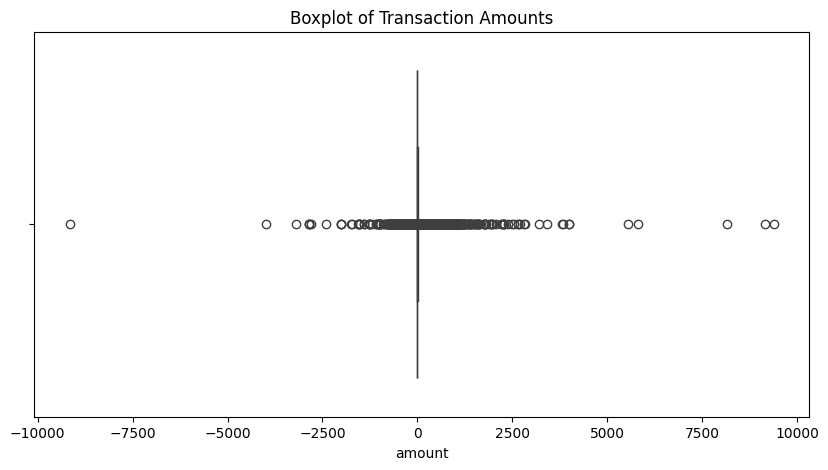

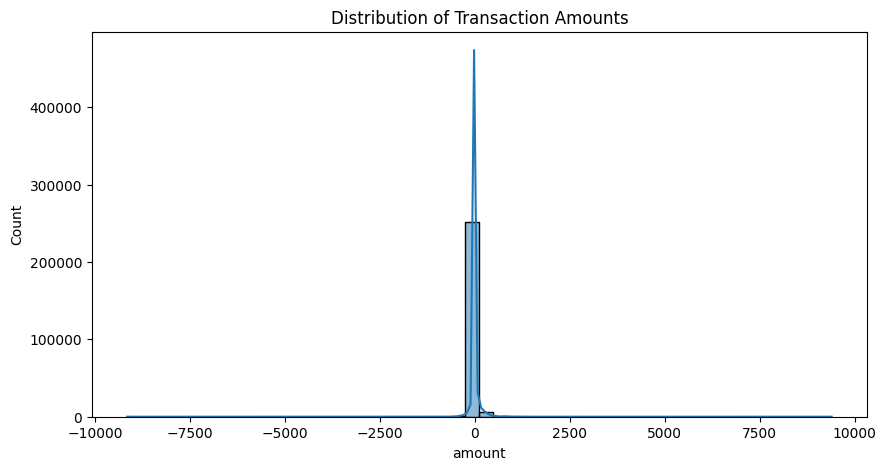

In [ ]:
# Boxplot to visualize outliers
plt.figure(figsize=(10,5))
sns.boxplot(x=data['amount'])
plt.title("Boxplot of Transaction Amounts")
plt.show()

# Histogram to check distribution
plt.figure(figsize=(10,5))
sns.histplot(data['amount'], bins=50, kde=True)
plt.title("Distribution of Transaction Amounts")
plt.show()

Most transactions are clustered around small amounts close to zero. There is a wide range of values with many large positive and negative outliers. This indicates high variability in the dataset.

In [ ]:
# Compute Q1, Q3, and IQR
Q1 = data["amount"].quantile(0.25)
Q3 = data["amount"].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = data[(data["amount"] < lower_bound) | (data["amount"] > upper_bound)]
print(f"Number of outliers: {len(outliers)}")

Number of outliers: 63624


About 25% of transactions are identified as outliers. Removing them could lead to data loss and bias. Instead of removing outliers completely, I applied a log transformation. Since the dataset contains both positive and negative values, I applied an absolute log transformation. This approach preserves all data while reducing the impact of extreme values. This can make the data more normally distributed for model training.

In [ ]:
data['amount'] = np.sign(data['amount']) * np.log1p(abs(data['amount']))

In [ ]:
# Check distribution again
data['amount'].describe()

,amount
count,258779.000000
mean,-0.478456
std,2.335367
min,-9.122979
25%,-1.945910
50%,-1.056400
75%,1.098612
max,9.148340


In [ ]:
category_counts = data['category_encoded'].value_counts()

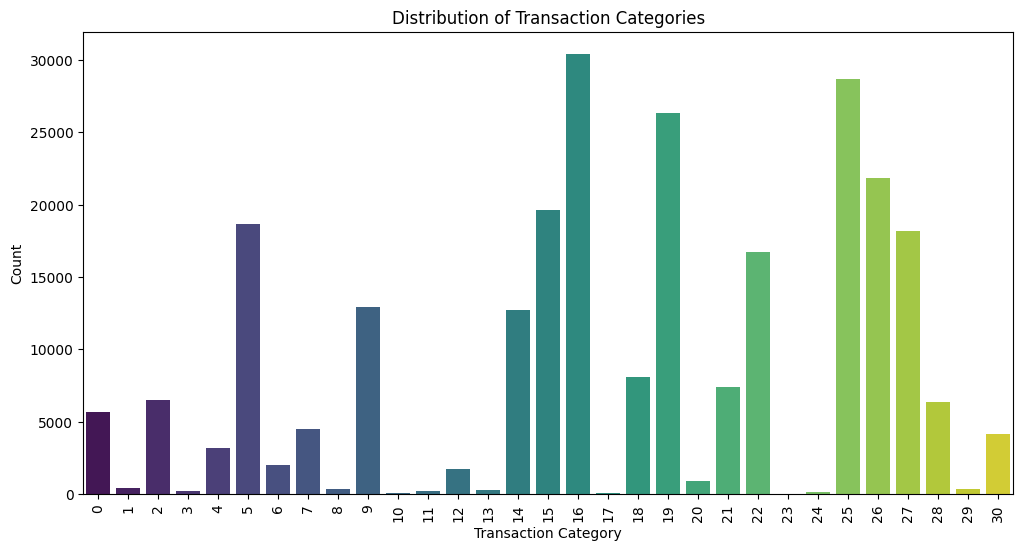

In [ ]:
# Plot the category distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=category_counts.index, y=category_counts.values, palette="viridis")

# Labels and title
plt.xlabel("Transaction Category")
plt.ylabel("Count")
plt.title("Distribution of Transaction Categories")
plt.xticks(rotation=90)
plt.show()

This bar chart clearly shows class imbalance. Some categories have significantly more samples than others, while a few categories have very low counts. This imbalance can negatively impact model performance by biasing predictions toward majority classes. Techniques like random undersampling and SMOTE should be conducted later to help mitigate this issue.

## Feature engineering

In [ ]:
# Extract day, month, and year from the 'txn_date' column
data["txn_day"] =data["txn_date"].dt.day
data["txn_month"] = data["txn_date"].dt.month
data["txn_year"] = data["txn_date"].dt.year

By breaking down the date column into day, month, and year, I captured important temporal features that can reveal patterns in the transaction data. These features help identify recurring transaction behaviors tied to specific calendar events, such as monthly payrolls.

In [ ]:
# Drop the 'txn_date' column
data = data.drop(columns=['txn_date'])

In [ ]:
# Convert the 'description' column to lowercase
data["description"] = data["description"].str.lower()

# Calculate the length of each description
data["description_length"] = data["description"].apply(len)

# Calculate the number of words in each description
data["word_count"] = data["description"].apply(lambda x: len(x.split()))

Converting the 'description' column to lowercase ensures text consistency, reduces variability to improve model performance. Calculating description_length helps identify patterns in transaction types, as longer descriptions may indicate detailed purchases, while shorter ones suggest simpler transactions. Extracting word_count provides insights into verbosity, which can differentiate categories where descriptions vary in detail. These features enhance text-based classification by adding meaningful numerical attributes to complement TF-IDF techniques.

In [ ]:
data.head()

,client_id,bank_id,account_id,txn_id,description,amount,category_encoded,is_interested_investment,is_interested_build_credit,is_interested_increase_income,is_interested_pay_off_debt,is_interested_manage_spending,is_interested_grow_savings,txn_day,txn_month,txn_year,description_length,word_count
0,1,1,1,4,earnin payment donat...,3.044522,15,0,0,0,0,0,0,29,9,2023,55,4
1,1,1,1,3,online transfer from ndonatas danyalda o carso...,3.258097,26,0,0,0,0,0,0,14,8,2023,75,11
2,1,1,1,5,money transfer author...,3.044522,15,0,0,0,0,0,0,25,9,2023,128,11
3,1,1,2,1,online transfer from carson n everyday checkin...,2.833213,26,0,0,0,0,0,0,2,6,2023,57,9
4,1,1,2,2,online transfer from carson n everyday checkin...,1.609438,26,0,0,0,0,0,0,1,6,2023,57,9


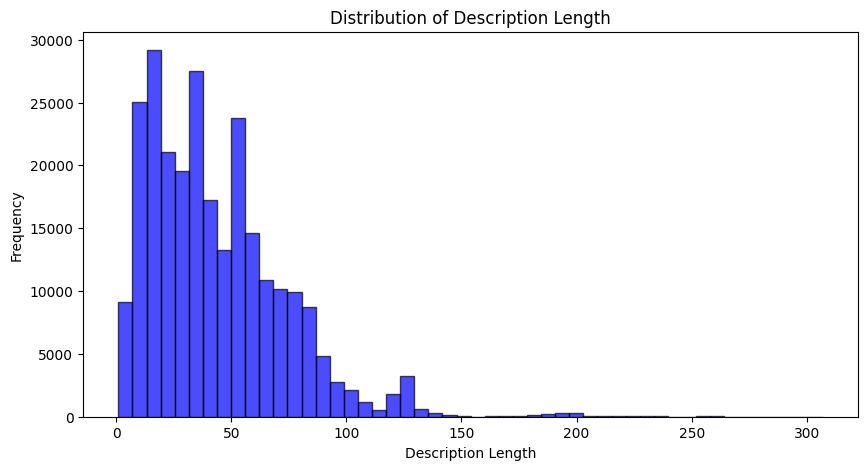

In [ ]:
# Plot histogram of description length
plt.figure(figsize=(10, 5))
plt.hist(data["description_length"], bins=50,color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Description Length")
plt.ylabel("Frequency")
plt.title("Distribution of Description Length")
plt.show()

This histogram shows the distribution of transaction description lengths. Most descriptions are short, with a peak around 10-50 characters. The frequency decreases as length increases, with very few descriptions exceeding 100 characters. The right tail indicates rare long descriptions.

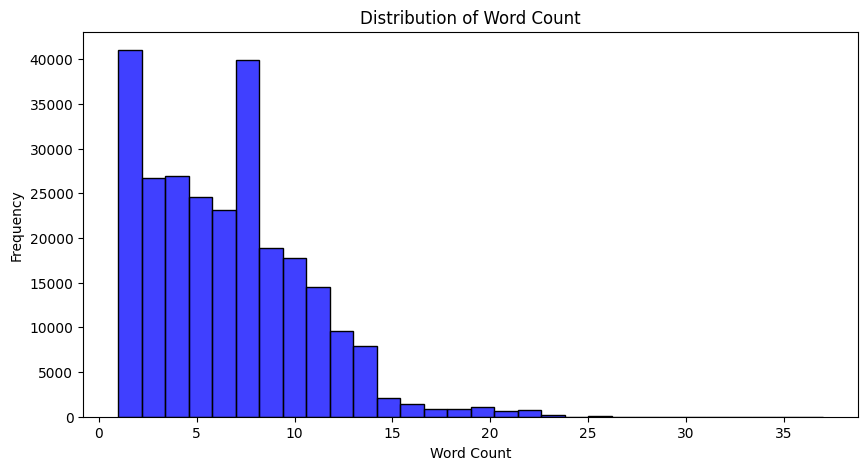

In [ ]:
# Plot histogram of word count
plt.figure(figsize=(10, 5))
sns.histplot(data['word_count'], bins=30,color='blue')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.title('Distribution of Word Count')
plt.show()

The distribution is right-skewed with most descriptions have fewer words (between 1-10 words).There are noticeable peaks at 1 and 7 words, indicating common lengths for transaction descriptions.
Only a few descriptions have more than 20 words.

# Text preprocessing

Natural Language Toolkit (NLTK) is  used for text preprocessing. Proper text preprocessing ensures that the LightGBM model effectively captures meaningful patterns from the text data. 

In [ ]:
nltk.download('stopwords')

# Load English stop words
stop_words = stopwords.words('english')

# Display stop words
np.array(stop_words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


array(['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you',
       "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself',
       'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her',
       'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them',
       'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom',
       'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are',
       'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had',
       'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and',
       'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at',
       'by', 'for', 'with', 'about', 'against', 'between', 'into',
       'through', 'during', 'before', 'after', 'above', 'below', 'to',
       'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under',
       'again', 'further', 'then', 'once', 'here', 'there', 'when',
       'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'm

### Removing Punctuation & Isolating Words

Punctuation and special characters do not contribute to meaning in classification.
Removing them ensures the model focuses on actual words rather than unnecessary symbols.

In [ ]:
def clean(text):
    """Remove punctuation & isolate words"""
    delimiters =  re.escape(string.punctuation)
    str_to_split = text
    result = re.findall(r'\b(?!\d+\b)\w+\b|' + delimiters, str_to_split)
    return " ".join([s for s in result if not re.match(delimiters, s)])

In [ ]:
# Apply clean function
data['description'] = data['description'].apply(clean)

In [ ]:
data['description'].head()

,description
0,earnin payment donatas danyal
1,online transfer from ndonatas danyalda o carso...
2,money transfer authorized on from earnin cdaej...
3,online transfer from carson n everyday checking
4,online transfer from carson n everyday checking


### Removing Stop Words

Stop words such as 'the', 'and', 'is' do not carry meaningful information for classification.
Removing them reduces noise to improve model efficiency and accuracy.

In [ ]:
def stopwords(text):
    """Remove stop words"""
    text = [word for word in text.split() if word not in stop_words]
    return " ".join(text)

In [ ]:
# Apply stopwords function
data['description'] = data['description'].apply(stopwords)

In [ ]:
data['description'].head()

,description
0,earnin payment donatas danyal
1,online transfer ndonatas danyalda carson busin...
2,money transfer authorized earnin cdaej_b ca s5...
3,online transfer carson n everyday checking
4,online transfer carson n everyday checking


### Stemming

Stemming converts words to their base form such as 'banks' to 'bank'. This reduces redundancy and helps in improving model generalization.


In [ ]:
stemmer = SnowballStemmer("english")

def stemming(text):
     """Apply stemming to each word using Snowball stemmer."""
     text = [stemmer.stem(word) for word in text.split()]
     return " ".join(text)

In [ ]:
# Apply stemming function
data['description'] = data['description'].apply(stemming)

In [ ]:
data['description'].head()

,description
0,earnin payment donata danyal
1,onlin transfer ndonata danyalda carson busi check
2,money transfer author earnin cdaej_b ca s58326...
3,onlin transfer carson n everyday check
4,onlin transfer carson n everyday check


In [ ]:
cols_to_scale = ['amount', 'description_length', 'word_count']

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the specified columns
data[cols_to_scale] = scaler.fit_transform(data[cols_to_scale])

Standard scaling is applied to 'amount', 'description_length', and 'word_count' to improve numerical stability and ensure balanced feature contributions. While LightGBM is scale-invariant, scaling can enhance regularization effectiveness (reg_alpha, reg_lambda) by ensuring penalties are applied uniformly. This helps control overfitting and improves model generalization.

In [ ]:
# Separate the features and the target variable
X = data.drop(columns=['category_encoded']).values
y = data['category_encoded'].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.3,stratify= y,random_state = 42)

A 30% test split ensures enough data for evaluation while keeping 70% for training to learn patterns effectively. Due to class imbalance in the dataset, stratifying by y is used to preserve the class distribution in both training and test sets to prevent bias. This improves model generalization and ensures reliable performance evaluation.

In [ ]:
# Convert X_train and X_test back to DataFrames
X_train = pd.DataFrame(X_train, columns=data.drop(columns=['category_encoded']).columns)
X_test = pd.DataFrame(X_test, columns=data.drop(columns=['category_encoded']).columns)

## Text vectorization using TF-IDF

TF-IDF (Term Frequency-Inverse Document Frequency) is used because it effectively transforms unstructured text from bank transaction descriptions into meaningful numerical features.

LightGBM handles sparse data well, making it a good match for TF-IDF, which produces high-dimensional sparse representations. TF-IDF helps the model focus on important words by assigning higher weights to rare but meaningful terms while downweighting common ones to reduce noise.

This allows LightGBM to better differentiate transaction types based on key terms. Additionally, both TF-IDF and LightGBM are computationally efficient. This makes them suitable for large-scale datasets.

In [ ]:
# Use TF-IDF vectorizer to convert text data into numerical features
tfidf = TfidfVectorizer(stop_words='english', lowercase=False,max_features = 1000)

# Train the vectorizer
tfidf.fit(X_train['description'])

# Retrieve the word-to-index mapping from the vectorizer
dictionary = tfidf.vocabulary_.items()

In [ ]:
# Transform train and test data to TF-IDF vectors
train_vector = tfidf.transform(X_train['description']).toarray()
print(f'Train vector shape : {train_vector.shape}')

test_vector =  tfidf.transform(X_test['description']).toarray()
print(f'Test vector shape : {test_vector.shape}')

Train vector shape : (181145, 1000)
Test vector shape : (77634, 1000)


## Dimensionality Reduction using PCA

Principal Component Analysis (PCA) is used to reduce dimensionality since TF-IDF generates 1000 features and the dataset is large with 258779 rows. This helps reduce computation time, remove redundant information, and improve model efficiency. Keeping 90% variance ensures minimal information loss while making the model training faster and reducing the risk of overfitting.

In [ ]:
# Use PCA for dimensionality reduction
pca = PCA(random_state=42)
pca.fit(train_vector)

PCA(random_state=42)

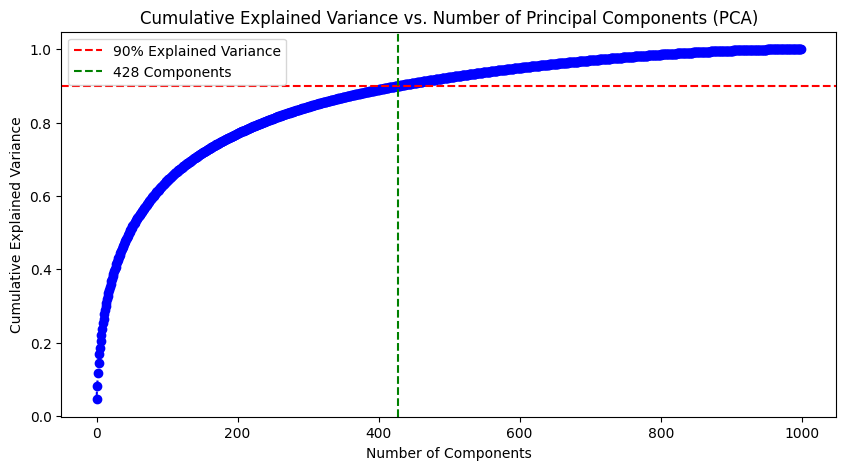

Number of components to explain 90% variance: 428


In [ ]:
# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Find the number of components that explain 90% variance
n_components_90 = np.argmax(cumulative_variance >= 0.9) + 1

# Plot cumulative explained variance for PCA components
plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.9, color='red', linestyle='--', label='90% Explained Variance')
plt.axvline(x=n_components_90, color='green', linestyle='--', label=f'{n_components_90} Components')
plt.title('Cumulative Explained Variance vs. Number of Principal Components (PCA)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.show()

print(f'Number of components to explain 90% variance: {n_components_90}')

In [ ]:
# Reduce the dimensionality while keeping 90% variance
pca = PCA(n_components=0.90, random_state=42)
pca.fit(train_vector)

PCA(n_components=0.9, random_state=42)

In [ ]:
# Apply PCA transformation
train_vector = pca.transform(train_vector)
test_vector  = pca.transform(test_vector)

print(train_vector.shape)
print(test_vector.shape)

(181145, 428)
(77634, 428)


In [ ]:
# Add PCA features to train and test data
X_train = np.concatenate((X_train, train_vector), axis=1)
X_test = np.concatenate((X_test, test_vector),axis=1)

In [ ]:
# Convert train and test data to DataFrame
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

In [ ]:
X_train.head()

,0,1,2,3,4,5,6,7,8,9,...,435,436,437,438,439,440,441,442,443,444
0,7,1,1,59,intuit direct dep,2.848673,0,0,0,0,...,-0.003259,0.001555,-0.011405,-0.005786,0.014136,-0.02892,-0.013561,-0.012729,0.030129,0.015223
1,289,1,1,60,wal mart assoc payrol,2.584947,0,0,0,0,...,0.001604,0.004602,-0.010378,-0.041925,0.008475,0.02258,-0.003298,-0.026829,-0.022326,0.016116
2,568,1,1,52,cash app cash visa direct caus,0.668102,1,0,0,0,...,0.001747,0.000213,0.001212,0.003429,0.000327,0.006277,0.004225,0.002754,-0.000432,0.00066
3,880,140,157,169149,withdraw paper fee,0.003619,0,0,0,0,...,-0.009266,0.004645,-0.00329,0.001709,-0.000584,-0.000852,0.005944,0.001275,0.00361,0.00053
4,880,651,750,55442,h e b check servic,-1.478729,0,0,0,0,...,0.004357,0.000726,0.002025,-0.00119,-0.00448,-0.002417,0.010726,-0.006038,-0.001088,0.005978


In [ ]:
# Drop the description column from X_train and X_test
X_train.drop(X_train.columns[4], axis=1, inplace=True)
X_test.drop(X_test.columns[4], axis=1, inplace=True)

# Reset column indices to make them contiguous
X_train.columns = range(X_train.shape[1])
X_test.columns = range(X_test.shape[1])

In [ ]:
X_train.head()

,0,1,2,3,4,5,6,7,8,9,...,434,435,436,437,438,439,440,441,442,443
0,7,1,1,59,2.848673,0,0,0,0,0,...,-0.003259,0.001555,-0.011405,-0.005786,0.014136,-0.02892,-0.013561,-0.012729,0.030129,0.015223
1,289,1,1,60,2.584947,0,0,0,0,0,...,0.001604,0.004602,-0.010378,-0.041925,0.008475,0.02258,-0.003298,-0.026829,-0.022326,0.016116
2,568,1,1,52,0.668102,1,0,0,0,0,...,0.001747,0.000213,0.001212,0.003429,0.000327,0.006277,0.004225,0.002754,-0.000432,0.00066
3,880,140,157,169149,0.003619,0,0,0,0,0,...,-0.009266,0.004645,-0.00329,0.001709,-0.000584,-0.000852,0.005944,0.001275,0.00361,0.00053
4,880,651,750,55442,-1.478729,0,0,0,0,0,...,0.004357,0.000726,0.002025,-0.00119,-0.00448,-0.002417,0.010726,-0.006038,-0.001088,0.005978


In [ ]:
training_data = pd.DataFrame(np.concatenate((X_train.values,y_train.reshape(-1,1)),axis=1))

In [ ]:
training_data.rename(columns={training_data.columns[-1]: 'category'}, inplace=True)

## SMOTE (Synthetic Minority Over-sampling Technique)

The dataset is highly imbalanced with some categories have significantly more samples than others. This can lead to biased predictions where the model favors majority classes and performs poorly on minority ones.

In [ ]:
# Calculate class counts in the train data
class_counts = training_data['category'].value_counts()
print("Original class distribution:")
print(class_counts)

Original class distribution:
category
16    21290
25    20100
19    18457
26    15292
15    13723
5     13041
27    12725
22    11725
9      9043
14     8926
18     5670
21     5193
2      4528
28     4458
0      3970
7      3167
30     2883
4      2233
6      1401
12     1228
20      637
1       278
29      257
8       240
13      196
3       148
11      145
24      111
10       48
17       29
23        3
Name: count, dtype: int64


**Majority classes** : Class 16 (21290 samples), Class 25 (20100 samples) and Class 19 (18457 samples) dominate the dataset.

**Minority classes** : Class 23 (only 3 samples), Class 17 (29 samples), and Class 10 (48 samples) are severely underrepresented.

**To address this issue:**

**Random Undersampling:** Reduces the size of majority classes by capping their sample count at the median class size. The median is chosen as it provides a balanced cutoff to prevent excessive data loss from majority classes while still addressing class imbalance. This ensures that no class overwhelms model learning while retaining enough data for effective training.

**SMOTE:** Increases the size of minority classes by generating synthetic samples instead of just duplicating existing ones. The median class size is used as the target to prevent excessive oversampling. This ensures a more natural class distribution while improving model generalization.

**Random Undersampling** and **SMOTE** are applied only to the training data to balance class distribution and improve model learning.
These techniques are not applied to the test data to preserve the real-world class distribution for a fair and realistic model evaluation.

In [ ]:
median_count = int(class_counts.median())
target_count = median_count
print("Setting target count to:", target_count)

# Undersample the majority classes
undersample_strategy = {cls: min(count, target_count) for cls, count in class_counts.items()}
undersampler = RandomUnderSampler(sampling_strategy=undersample_strategy, random_state=42)

# Ensure the target column is integer
training_data['category'] = training_data['category'].astype(int)

X = training_data.drop(columns=['category'])
y = training_data['category']
X_under, y_under = undersampler.fit_resample(X, y)

print("Class distribution after undersampling:")
print(pd.Series(y_under).value_counts())

# Oversample the minority classes using SMOTE
undersampled_counts = pd.Series(y_under).value_counts().to_dict()
oversample_strategy = {cls: target_count for cls, count in undersampled_counts.items() if count < target_count}
print("Oversampling strategy:", oversample_strategy)

if oversample_strategy:
    smote = SMOTE(sampling_strategy=oversample_strategy, k_neighbors=1, random_state=42)
    X_final, y_final = smote.fit_resample(X_under, y_under)
else:
    X_final, y_final = X_under, y_under

print("Final balanced class distribution:")
print(pd.Series(y_final).value_counts())
print("Final dataset shape:", X_final.shape)

Setting target count to: 3167
Class distribution after undersampling:
category
0     3167
2     3167
5     3167
9     3167
14    3167
7     3167
28    3167
26    3167
25    3167
21    3167
22    3167
19    3167
18    3167
16    3167
15    3167
27    3167
30    2883
4     2233
6     1401
12    1228
20     637
1      278
29     257
8      240
13     196
3      148
11     145
24     111
10      48
17      29
23       3
Name: count, dtype: int64
Oversampling strategy: {30: 3167, 4: 3167, 6: 3167, 12: 3167, 20: 3167, 1: 3167, 29: 3167, 8: 3167, 13: 3167, 3: 3167, 11: 3167, 24: 3167, 10: 3167, 17: 3167, 23: 3167}
Final balanced class distribution:
category
0     3167
1     3167
2     3167
3     3167
4     3167
5     3167
6     3167
7     3167
8     3167
9     3167
10    3167
11    3167
12    3167
13    3167
14    3167
15    3167
16    3167
17    3167
18    3167
19    3167
20    3167
21    3167
22    3167
23    3167
24    3167
25    3167
26    3167
27    3167
28    3167
29    3167
30    3167


## Model training

**Why I choose LightGBM ?**

✅ Handles Large Datasets Efficiently

The dataset consists of 258779 rows, and LightGBM is designed for fast training on large datasets.
It is significantly faster than other gradient boosting models like XGBoost which makes it ideal for large-scale bank transaction category classification.

✅ Works Well with High-Dimensional Features

LightGBM efficiently handles both structured (numerical + categorical) and unstructured (text) data.
It supports TF-IDF features extracted from transaction descriptions that allows better text-based categorization.

✅ Effectively Handles Class Imbalance

LightGBM incorporates balanced boosting techniques to manage rare transaction categories.
It automatically adjusts class weights to prevent the model from being biased toward majority classes.

In [ ]:
# Ensure numeric data types
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Ensure y labels are integers
y_train = y_train.astype(int)
y_test = y_test.astype(int)

num_classes = len(np.unique(y_train))

In [ ]:
# Define the model with well-specified parameters
model = lgb.LGBMClassifier(
    class_weight='balanced',
    boosting_type='gbdt',          # Gradient Boosting Decision Tree
    objective='multiclass',        # Multiclass classification
    num_class=num_classes,         # Number of classes
    learning_rate=0.1,             # Controls step size
    n_estimators=100,              # Number of boosting rounds
    max_depth=-1,                  # No depth limit (let LightGBM decide)
    num_leaves=50,                 # Controls tree complexity
    min_child_samples=30,          # Minimum data per leaf
    subsample=0.8,                 # Fraction of samples per tree
    colsample_bytree=0.8,          # Fraction of features per tree
    reg_alpha=0.1,                 # L1 regularization
    reg_lambda=0.1,                # L2 regularization
    random_state=42                # Ensures reproducibility
)

# Train the model
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_metric='multi_logloss',      # Multiclass log loss metric
    callbacks=[
        early_stopping(stopping_rounds=10),
        log_evaluation(10)]
    )

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.136771 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 110698
[LightGBM] [Info] Number of data points in the train set: 181145, number of used features: 443
[LightGBM] [Info] Start training from score -3.433987
[LightGBM] [Info] Start training from score -3.433987
[LightGBM] [Info] Start training from score -3.433987
[LightGBM] [Info] Start training from score -3.433987
[LightGBM] [Info] Start training from score -3.433987
[LightGBM] [Info] Start training from score -3.433987
[LightGBM] [Info] Start training from score -3.433987
[LightGBM] [Info] Start training from score -3.433987
[LightGBM] [Info] Start training from score -3.433987
[LightGBM] [Info] Start training from score -3.433987
[LightGBM] [Info] Start training from score -3.433987
[LightGBM] [Info] Start training from score -3.433987
[LightGBM] [Info] Start training from score -3.433987
[Ligh

LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
               min_child_samples=30, num_class=31, num_leaves=50,
               objective='multiclass', random_state=42, reg_alpha=0.1,
               reg_lambda=0.1, subsample=0.8)

**Model Architecture: Gradient Boosting Decision Trees (GBDT) built on LightGBM**

o	The model sequentially builds trees with each new tree learning to correct the mistakes of the previous trees.

o	LightGBM uses histogram-based learning which  makes training faster and more memory-efficient compared to traditional GBDTs.

o	Tree structure uses leaf-wise growth rather than depth-wise.

o   This allows the model to capture complex patterns with fewer trees which makes it highly efficient.

**Multiclass Classification**

**Objective: multiclass**\
    o	This indicates that the model is performing a multi class classification task with 31 categories.

**Loss Function: multi_logloss**\
    o	Multiclass Log Loss metric optimizes probabilistic predictions to ensure that the model correctly assigns probabilities to multiple classes.

**Regularization and Overfitting Control**

**Tree Complexity Control:**\
    o	num_leaves=50: Limits the number of leaves per tree to control model complexity.\
    o	max_depth=-1: No fixed depth, allowing LightGBM to decide the best structure.\
    o	min_child_samples=30: Ensures that each leaf has at least 30 samples to prevent overly specific splits.

**Feature and Data Sampling:**\
    o	subsample=0.8: Uses 80% of the data per boosting iteration to add randomness and avoid overfitting.\
    o	colsample_bytree=0.8: Uses 80% of features per tree to diversify trees.

**Regularization:**\
    o	reg_alpha=0.1 (L1 regularization): Helps induce sparsity in feature selection.\
    o	reg_lambda=0.1 (L2 regularization): Helps prevent overfitting by penalizing large coefficients.


**Model Optimization and Training Strategy**

**Balanced Class Weights:**\
    o	Automatically adjusts weights to handle class imbalance.

**Early Stopping:**\
    o	Stops training if validation loss doesn't improve for 10 rounds. Prevents unnecessary computation and overfitting.

**Hyperparameter Choices and Justifications**

learning_rate=0.1: A moderate value to balance speed and accuracy

n_estimators=100 : Standard initial choice of boosing rounds

num_leaves=50 : Balances model flexibility and overfitting

min_child_samples=30 : Prevents overly specific tree splits

subsample=0.8 : Introduces randomness to avoid overfitting

colsample_bytree=0.8 : Reduces dependency on specific features

reg_alpha=0.1, reg_lambda=0.1   : Controls overfitting

In [ ]:
# Save the trained model
model.booster_.save_model('lightgbm_model.txt')

## Model evaluation

In [ ]:
# Calculate accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9273


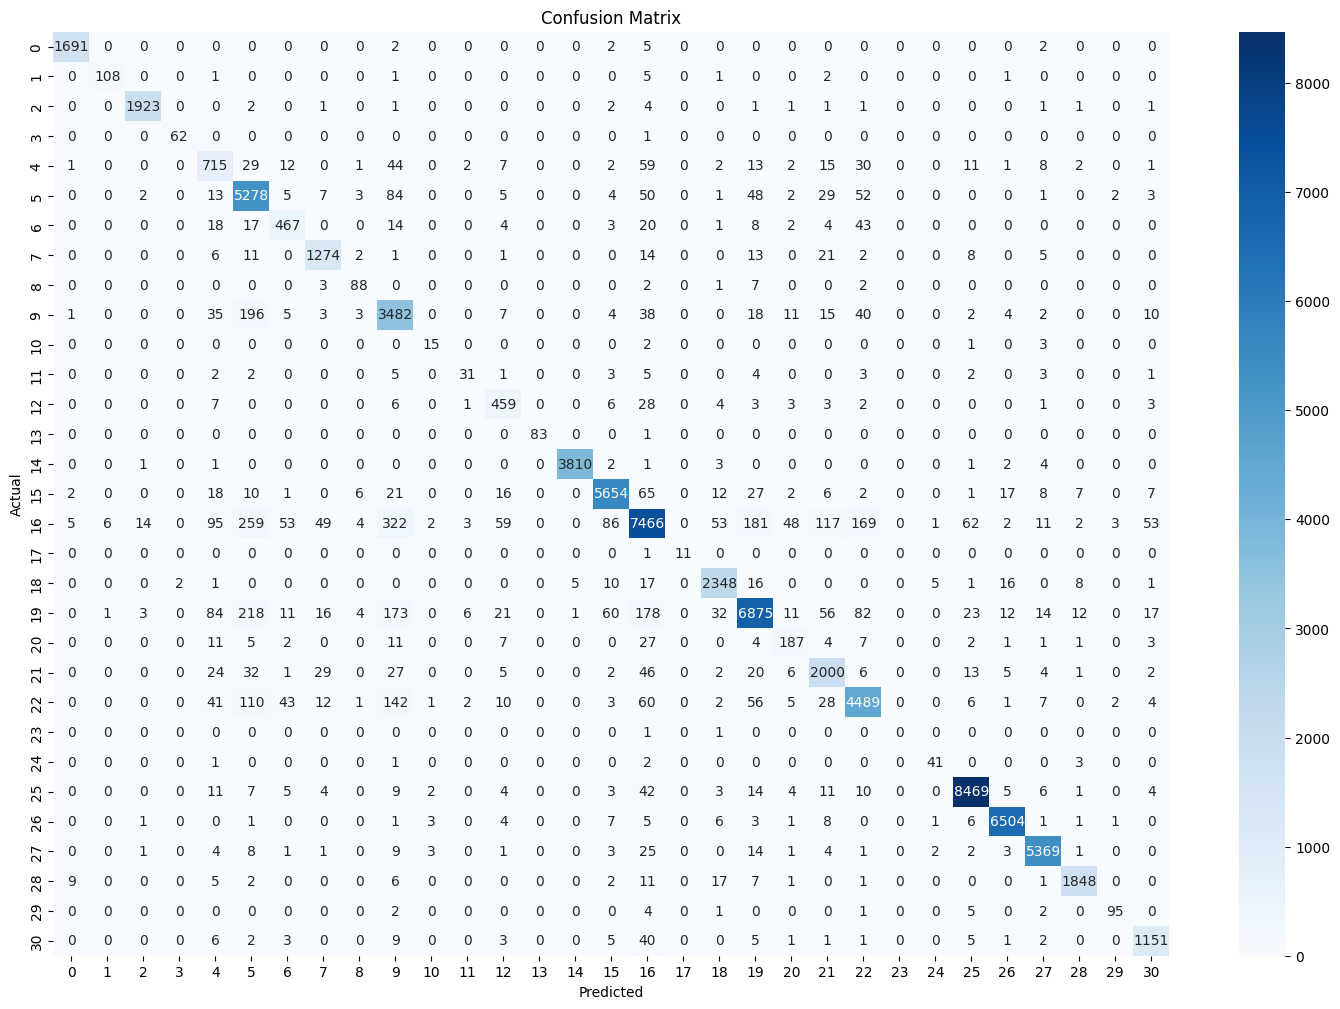

In [ ]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(18, 12))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

The confusion matrix exhibits a diagonal pattern which  indicates good model performance in many classes. However, notable off-diagonal misclassifications suggest that the model struggles to distinguish certain categories, particularly in classes with overlapping features or imbalanced representation.

For example, Class 14 (Payment) has 3810 correct predictions with minimal misclassifications. Class 26 (Transfer Credit) has 6504 correct predictions with few misclassifications. The strong, concentrated diagonal indicates the model confidently distinguishes both classes from others.

In [ ]:
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

                            precision    recall  f1-score   support

                       ATM       0.99      0.99      0.99      1702
    Arts and Entertainment       0.94      0.91      0.92       119
                 Bank Fees       0.99      0.99      0.99      1940
             Check Deposit       0.97      0.98      0.98        63
  Clothing and Accessories       0.65      0.75      0.70       957
        Convenience Stores       0.85      0.94      0.90      5589
         Department Stores       0.77      0.78      0.77       601
     Digital Entertainment       0.91      0.94      0.92      1358
Food and Beverage Services       0.79      0.85      0.82       103
              Gas Stations       0.80      0.90      0.84      3876
  Gyms and Fitness Centers       0.58      0.71      0.64        21
                Healthcare       0.69      0.50      0.58        62
                 Insurance       0.75      0.87      0.81       526
                  Interest       1.00      0.99

This classification report evaluates the LightGBM model using precision, recall, and F1-score across various categories. Since the dataset is imbalanced, the weighted average is the more appropriate metric for assessing overall model performance.

The model achieves a high overall accuracy of 93%, with a weighted score of 0.93 for precision, recall and F1-score. This indicates strong performance across most categories.

Among the strong-performing categories, Internal Account Transfer achieves a perfect score (1.00) for precision, recall and F1-score. This suggests that the model has learned strong patterns for this category, likely due to clear transaction characteristics and a high number of samples.

Other high-performing categories include ATM, Bank Fees, Interest, Transfer Credit, Transfer Debit, Transfer Deposit, Third Party, and Loans, all of which have very high scores. This indicates that the model effectively classifies well-represented transaction types which makes it highly reliable for these categories.

Categories such as Food and Beverage Services, Gas Stations, Insurance, and Telecommunications show decent performance, but some misclassifications exist. While the model is fairly reliable in these cases, there is room for improvement.

However, performance drops for categories like Gyms and Fitness Centers, Healthcare and Service where the model struggles with classification. This is likely due to data imbalance or overlapping transaction descriptions.

Tax Refund has the lowest performance (F1: 0.00), where the model fails to classify any instances correctly. This is due to extreme class imbalance (only 2 samples). To improve classification for this category, additional data collection is necessary to provide the model with sufficient examples to learn from.

In [ ]:
# Compute ROC-AUC Score (Overall Performance)
probs = model.predict_proba(X_test)

# Compute ROC-AUC score for multi-class
roc_auc = roc_auc_score(y_test, probs, multi_class='ovr')

In [ ]:
print(f"Overall ROC-AUC Score: {roc_auc:.4f}")

Overall ROC-AUC Score: 0.9901


The ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) score measures the model's ability to distinguish between different transaction categories. A score close to 1.00 indicates excellent predictive performance. The model achieves a score of 0.9901 which is very high. This suggests that the model is highly effective at ranking correct categories higher than incorrect ones across all classes.

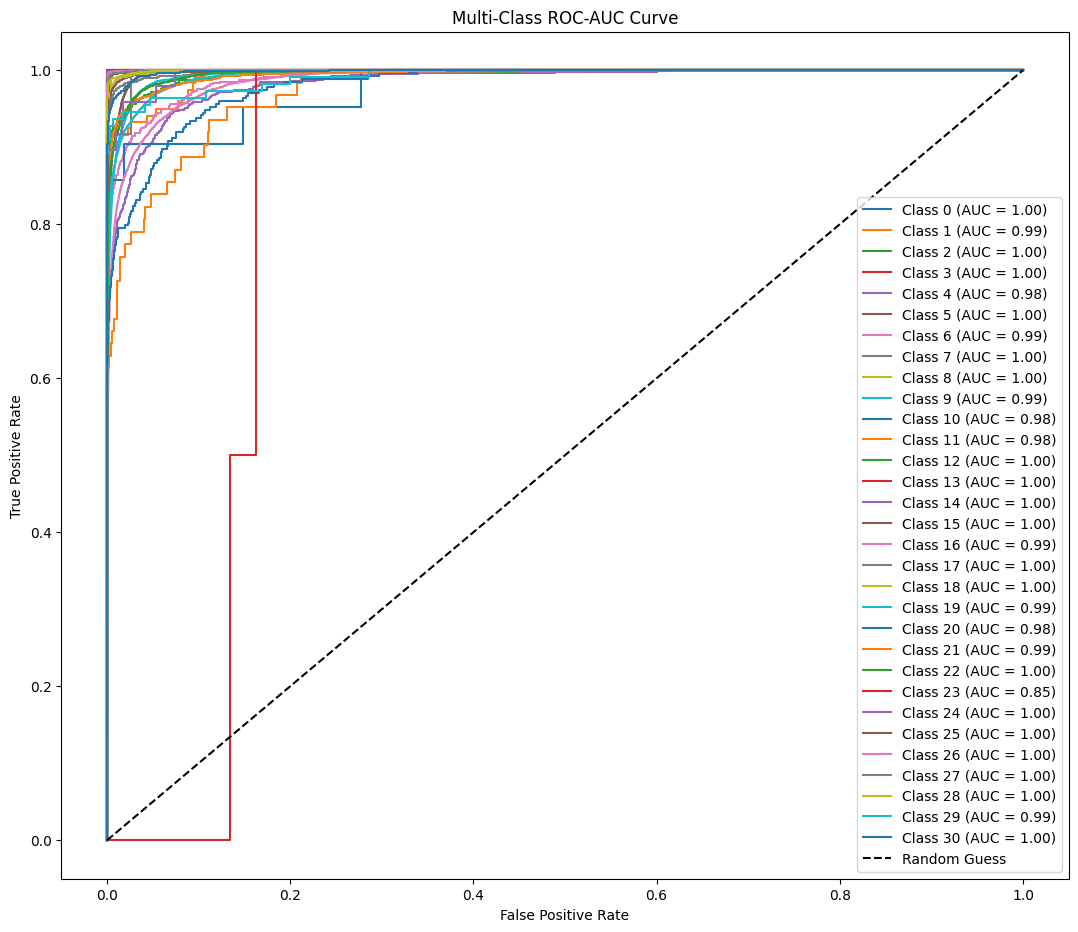

In [ ]:
# Plot Multi-Class ROC Curves
# Binarize y_test labels
y_test_bin = label_binarize(y_test, classes=np.unique(y_train))
num_classes = y_test_bin.shape[1]  # Number of classes

# Plot ROC curves for each class
plt.figure(figsize=(13, 11))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])  # Compute ROC curve
    roc_auc = auc(fpr, tpr)  # Compute AUC score for this class
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

# Plot random baseline (dotted diagonal)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC-AUC Curve')
plt.legend(loc='lower right')
plt.show()

The model performs exceptionally well, with most classes achieving an AUC close to 1.0. Many classes also have values around 0.98 to 0.99 which indicates excellent discrimination. Only one class, Class 23 (Tax Refund)has an AUC of 0.85. It shows slightly lower performance which requires further optimization.

Overall, the model is highly effective in predicting bank transaction categories with minimal performance concerns.